# Suggesting scores for written answers

QuizBank grades multiple-choice and fill-in-the-blank answers on its own, but written
answers wait for the instructor. This notebook builds and measures a model that
**suggests** a score for each written answer, which the instructor accepts or changes.

**Data.** The UNT Computer Science Short Answer dataset (Mohler, Bunescu & Mihalcea,
ACL 2011): 2,273 answers from an intro computer science course to 81 questions, each
with the instructor's model answer, scored 0 to 5 by two human graders. It's downloaded
from its source on first run and not stored in the repository.

**The rule that shapes everything.** In the app, the model always grades questions it
has never seen: an instructor's own quiz. So it's trained and tested with
**question-grouped cross-validation**: in each of 5 folds, all the answers to a set of
questions are held out together. A random split would let the model memorize each
question's model answer and look far better than it would be in use.

**What "good" means.** Two humans grading the same answers don't agree perfectly either.
Their agreement with each other is the practical ceiling, and the published result on
this dataset (Pearson r = 0.518, Mohler et al. 2011) is the baseline to beat.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bank.ml import datasets, essay_grader as eg

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)
SURFACE, INK, INK_2, GRID, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#b9b8b3"
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 90)

df = datasets.load_unt(Path.cwd().parent / "data")
print(f"{len(df):,} answers to {df.question_id.nunique()} questions; "
      f"{df.answer.str.split().str.len().median():.0f} words per answer (median)")

2,273 answers to 81 questions; 16 words per answer (median)


## The data

Scores lean high: most students earned most of the credit. That matters for reading the
results, because a model can look accurate just by predicting "about 4" for everyone.
The *average score* baseline below measures exactly that.

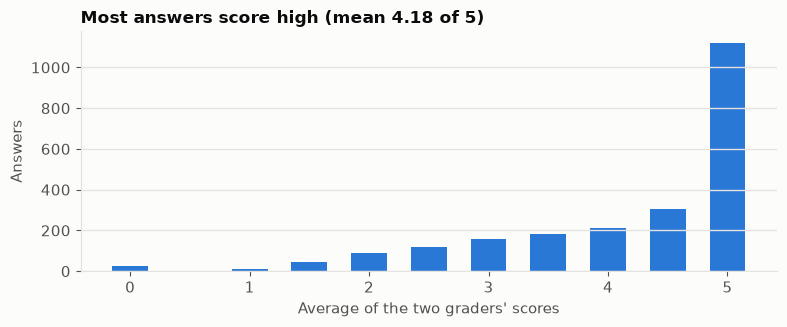

In [2]:
fig, ax = plt.subplots(figsize=(8, 3.4))
counts = df.score.value_counts().sort_index()
ax.bar(counts.index, counts.values, width=0.3, color=BLUE)
ax.set_xlabel("Average of the two graders' scores")
ax.set_ylabel("Answers")
ax.set_title(f"Most answers score high (mean {df.score.mean():.2f} of 5)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIGURES / "01_score_distribution.png", dpi=150)

## The ceiling: how much do two humans agree?

Each answer was scored by two graders. (The two exams were graded out of 10; QuizBank's
loader puts both graders on the 0-5 scale, matching the dataset's averaged score.)

In [3]:
humans = pd.DataFrame([eg.human_agreement(df)], index=["grader 1 vs grader 2"])
humans

,pearson,rmse,mae,qwk
grader 1 vs grader 2,0.597,1.311,0.748,0.491


## Features

Every feature compares the student's answer with the question's model answer (or the
question itself), so none of them depends on which question it is:

| Feature | What it measures |
|---|---|
| `emb_sim` | Similarity in meaning to the model answer (MiniLM sentence embeddings) |
| `emb_q_sim` | Similarity to the question (answers that only restate it score low) |
| `tfidf_sim` | Word overlap with the model answer, weighting rare words more (TF-IDF) |
| `recall` | Share of the model answer's key words the student used |
| `precision` | Share of the student's key words found in the model answer |
| `log_len`, `len_ratio` | Answer length, and length relative to the model answer |

## Models compared

From simplest to most complex. Each is scored on held-out questions only.

In [4]:
folds, predictions = eg.cross_validate(df, embedder="minilm", n_splits=5)
table = (folds.groupby("model", sort=False)[["pearson", "qwk", "mae", "rmse"]]
         .agg(["mean", "std"]).round(3))
table

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

pearson           qwk           mae         \
                                   mean    std   mean    std   mean    std   
model                                                                        
Average score                     0.000  0.000  0.000  0.000  0.894  0.042   
Length only                       0.169  0.127  0.002  0.019  0.871  0.050   
Word overlap (TF-IDF)             0.421  0.073  0.203  0.072  0.755  0.109   
Meaning (embeddings)              0.507  0.050  0.351  0.040  0.729  0.068   
All features, ridge               0.562  0.078  0.427  0.081  0.679  0.108   
All features, gradient boosting   0.493  0.106  0.437  0.091  0.701  0.115   

                                  rmse         
                                  mean    std  
model                                          
Average score                    1.099  0.079  
Length only                      1.083  0.087  
Word overlap (TF-IDF)            0.997  0.099  
Meaning (embeddings)             0.958  0.077  
All features, ridge              0.911  0.100  
All features, gradient boosting  0.980  0.128

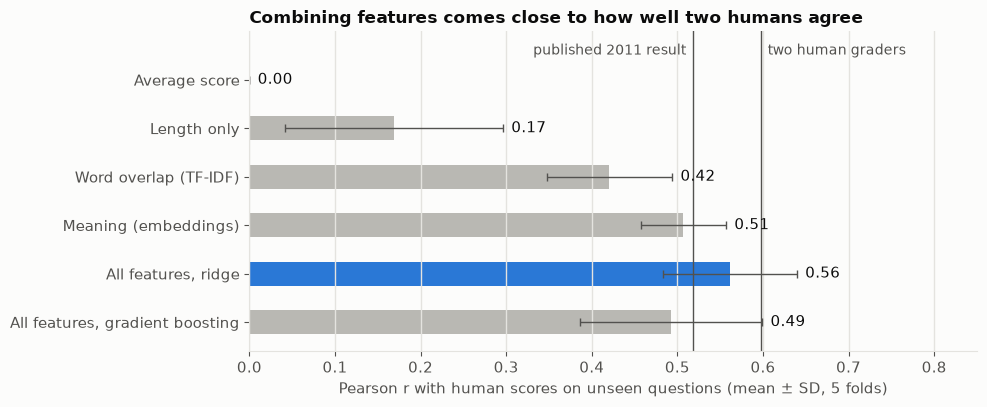

In [5]:
means = folds.groupby("model", sort=False)["pearson"].agg(["mean", "std"])
human_r = eg.human_agreement(df)["pearson"]
fig, ax = plt.subplots(figsize=(10, 4.2))
colors = [BLUE if name == eg.FINAL_MODEL else MUTED for name in means.index]
y = np.arange(len(means))[::-1]
ax.barh(y, means["mean"], height=0.5, color=colors, xerr=means["std"],
        error_kw={"ecolor": INK_2, "elinewidth": 1, "capsize": 3})
ax.set_yticks(y, means.index)
for yi, value, spread in zip(y, means["mean"], means["std"].fillna(0)):
    ax.annotate(f"{value:.2f}", (value + spread, yi), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK)
for x, label, side in [(0.518, "published 2011 result", "right"), (human_r, "two human graders", "left")]:
    ax.axvline(x, color=INK_2, linewidth=1)
    ax.annotate(label, (x, y.max() + 0.6), xytext=(-5 if side == "right" else 5, 0), textcoords="offset points",
                ha=side, va="center", color=INK_2, fontsize=10)
ax.set_xlim(0, 0.85)
ax.set_ylim(-0.6, y.max() + 1.0)
ax.set_xlabel("Pearson r with human scores on unseen questions (mean ± SD, 5 folds)")
ax.grid(axis="y", visible=False)
ax.set_title("Combining features comes close to how well two humans agree")
fig.tight_layout()
fig.savefig(FIGURES / "01_model_comparison.png", dpi=150)

## Where the chosen model goes wrong

The chosen model is ridge regression on all the features: best correlation and lowest
error on held-out questions, and its coefficients are easy to explain. Gradient boosting,
with the same features, did worse, which is what overfitting looks like with only 81
questions to learn from.

In [6]:
chosen = predictions[eg.FINAL_MODEL]
band = df.score.round().astype(int)
by_band = pd.DataFrame({"answers": band.value_counts().sort_index(),
                        "mean prediction": chosen.groupby(band).mean(),
                        "mean abs error": (chosen - df.score).abs().groupby(band).mean()})
by_band

,answers,mean prediction,mean abs error
score,,,
0,26,2.900,2.843
1,11,3.372,2.372
2,254,3.645,1.494
3,159,3.789,0.803
4,702,4.011,0.453
5,1121,4.448,0.552


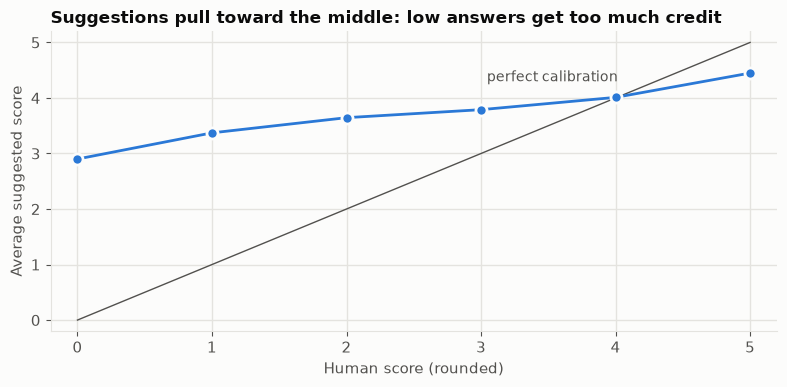

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
lo, hi = 0, 5
ax.plot([lo, hi], [lo, hi], color=INK_2, linewidth=1)
ax.plot(by_band.index, by_band["mean prediction"], color=BLUE, linewidth=2, marker="o", markersize=8,
        markeredgecolor=SURFACE, markeredgewidth=2)
ax.annotate("perfect calibration", (4.1, 4.1), xytext=(-8, 8), textcoords="offset points",
            color=INK_2, ha="right", fontsize=10)
ax.set_xlabel("Human score (rounded)")
ax.set_ylabel("Average suggested score")
ax.set_xlim(-0.2, 5.2)
ax.set_ylim(-0.2, 5.2)
ax.set_title("Suggestions pull toward the middle: low answers get too much credit")
fig.tight_layout()
fig.savefig(FIGURES / "01_calibration.png", dpi=150)

In [8]:
errors = df.assign(suggested=chosen.round(1), error=(chosen - df.score).round(1))
cols = ["question", "reference", "answer", "score", "suggested"]
print("Biggest overestimates (the model gave too much credit):")
display(errors.nlargest(4, "error")[cols])
print("Biggest underestimates (too little credit):")
display(errors.nsmallest(4, "error")[cols])

Biggest overestimates (the model gave too much credit):


,question,reference,answer,score,suggested
94,Where do C++ programs begin to execute?,At the main function.,in the testing phase,0.0,3.6
323,How many constructors can be created for a class?,Unlimited number.,Just one per class.,0.0,3.4
328,How many constructors can be created for a class?,Unlimited number.,1,0.0,3.3
330,How many constructors can be created for a class?,Unlimited number.,One,0.0,3.3


Biggest underestimates (too little credit):


,question,reference,answer,score,suggested
304,When does C++ create a default constructor?,"If no constructor is provided, the compiler provides one by default. If a constructor ...",whenevery you dont specifiy your own,5.0,2.7
563,How are overloaded functions differentiated by the compiler?,"Based on the function signature. When an overloaded function is called, the compiler w...",paremeters,4.5,2.2
1709,How many comparisons does it take to find an element in a binary search tree?,The height of the tree (or log of the number of elements in the tree).,logn,5.0,2.8
2128,What is the advantage of linked lists over arrays?,"Linked lists are dynamic structures, which allow for a variable number of elements to ...",they are resizeable,5.0,2.8


## What the model relies on

Ridge coefficients on standardized features: how much the suggested score moves for a
one-standard-deviation change in each feature, with the others held fixed.

emb_q_sim   -0.096
tfidf_sim   -0.052
precision    0.049
log_len      0.077
len_ratio    0.154
recall       0.254
emb_sim      0.407
dtype: float64

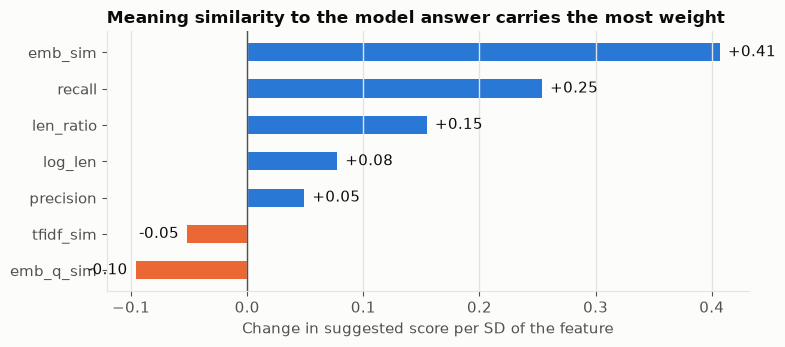

In [9]:
final = eg.train(df, embedder="minilm")
ridge = final.model[-1]
coefficients = pd.Series(ridge.coef_, index=eg.FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(coefficients.index, coefficients.values, height=0.5,
        color=[BLUE if v > 0 else ORANGE for v in coefficients.values])
ax.axvline(0, color=INK_2, linewidth=1)
for name, value in coefficients.items():
    ax.annotate(f"{value:+.2f}", (value, name), xytext=(6 if value > 0 else -6, 0), textcoords="offset points",
                ha="left" if value > 0 else "right", va="center", color=INK)
ax.set_xlabel("Change in suggested score per SD of the feature")
ax.grid(axis="y", visible=False)
ax.set_title("Meaning similarity to the model answer carries the most weight")
fig.tight_layout()
fig.savefig(FIGURES / "01_coefficients.png", dpi=150)
coefficients.round(3)

In [10]:
summary = eg.metrics(df.score, chosen)
human = eg.human_agreement(df)
within_one = float(((chosen - df.score).abs() <= 1).mean())
print(f"Held-out questions: r = {summary['pearson']:.3f}, QWK = {summary['qwk']:.3f}, "
      f"MAE = {summary['mae']:.3f}, within 1 point: {within_one:.1%}")
print(f"Two human graders:  r = {human['pearson']:.3f}, QWK = {human['qwk']:.3f}, MAE = {human['mae']:.3f}")

Held-out questions: r = 0.552, QWK = 0.429, MAE = 0.679, within 1 point: 75.8%
Two human graders:  r = 0.597, QWK = 0.491, MAE = 0.748


## Conclusions

- **It works about as well as a second human grader, by correlation.** On questions it
  never saw, the suggestions reach r = 0.55 with the graders' average score (0.56 averaged
  over folds), close to the r = 0.60 between the two human graders, and above the published
  result on this dataset (0.518). They land within 1 point of the human score 76% of the time.
- **Meaning beats word matching.** Sentence embeddings alone (0.51) beat TF-IDF word
  overlap (0.42), and combining them with coverage and length features adds more (0.56).
- **Simple beat complex.** Gradient boosting did worse than ridge regression on the same
  features: with only 81 questions, it overfits to them.
- **The main weakness: short wrong answers get too much credit.** Answers the humans
  scored 0 got about 2.9 of 5 on average. "One" for "how many constructors can a class
  have?" (answer: unlimited) looks close to the model answer, because the model measures
  similarity, not correctness. Short correct answers with typos ("paremeters") get too
  little. The app says this next to every suggestion, and the instructor always decides.
- **Limits of the evidence.** One course, one instructor's questions, from 2011. The
  honest claim is "a useful starting point for grading", not "a grader".